In [36]:
import os
BASE_PATH = r"E:\MEDICAL IMAGING\kl_dataset\kl_dataset"
KL0_PATH = os.path.join(BASE_PATH, "KL0")
KL34_PATH = os.path.join(BASE_PATH, "KL34")

print("KL0 files:", len(os.listdir(KL0_PATH)))
print("KL34 files:", len(os.listdir(KL34_PATH)))

KL0 files: 47
KL34 files: 46


In [37]:
kl0_files = [os.path.join(KL0_PATH, f) for f in os.listdir(KL0_PATH)]
kl34_files = [os.path.join(KL34_PATH, f) for f in os.listdir(KL34_PATH)]

all_files = kl0_files + kl34_files

In [38]:
sample_files = all_files[:10]
print(sample_files)

['E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\.DS_Store', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9019406_20050617_10934212', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9021195_20050531_10534714', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9059339_20040927_10127706', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9067323_20041001_10074106', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9072461_20050726_10442809', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9117692_20050909_10499806', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9126497_20050223_10716806', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9167018_20050801_10450312', 'E:\\MEDICAL IMAGING\\kl_dataset\\kl_dataset\\KL0\\9173462_20041027_10132712']


In [39]:
import os

BASE_PATH = r"E:\MEDICAL IMAGING\kl_dataset\kl_dataset"
KL0_PATH = os.path.join(BASE_PATH, "KL0")
KL34_PATH = os.path.join(BASE_PATH, "KL34")

kl0_cases = [f for f in os.listdir(KL0_PATH) if f != ".DS_Store"]
kl34_cases = [f for f in os.listdir(KL34_PATH) if f != ".DS_Store"]

print("KL0 cases:", len(kl0_cases))
print("First 5 KL0 case folders:", kl0_cases[:5])

print("\nKL34 cases:", len(kl34_cases))
print("First 5 KL34 case folders:", kl34_cases[:5])

KL0 cases: 46
First 5 KL0 case folders: ['9019406_20050617_10934212', '9021195_20050531_10534714', '9059339_20040927_10127706', '9067323_20041001_10074106', '9072461_20050726_10442809']

KL34 cases: 46
First 5 KL34 case folders: ['9001104_20050825_10498205', '9002430_20050620_10934806', '9037823_20040916_10242812', '9048192_20040823_10116511', '9048898_20050428_10330106']


In [40]:
# inside one KL0 case
sample_kl0 = os.path.join(KL0_PATH, kl0_cases[0])
print("KL0 sample contents:", os.listdir(sample_kl0)[:10])

# inside one KL34 case
sample_kl34 = os.path.join(KL34_PATH, kl34_cases[0])
print("KL34 sample contents:", os.listdir(sample_kl34)[:10])

KL0 sample contents: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
KL34 sample contents: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']


In [41]:
import os

sample_kl0 = os.path.join(KL0_PATH, kl0_cases[0])

files = [f for f in os.listdir(sample_kl0) if not f.startswith(".")]

print("Number of files in case:", len(files))
print("First 5 files:", files[:5])

Number of files in case: 160
First 5 files: ['001', '002', '003', '004', '005']


In [42]:
!pip install pydicom

In [43]:
# load middle slice of each MRI scan

import os
import numpy as np
import pydicom
from skimage.transform import resize

IMG_SIZE = 128

def load_middle_slice(case_path):
    files = sorted([f for f in os.listdir(case_path) if not f.startswith(".")])
    mid_file = files[len(files)//2]
    file_path = os.path.join(case_path, mid_file)

    ds = pydicom.dcmread(file_path)
    img = ds.pixel_array.astype(np.float32)

    # normalize (VERY IMPORTANT)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # resize
    img = resize(img, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)

    return img

X = []
y = []

# KL0 → label 0
for case in kl0_cases:
    case_path = os.path.join(KL0_PATH, case)
    try:
        X.append(load_middle_slice(case_path))
        y.append(0)
    except:
        print("Error KL0:", case)

# KL34 → label 1
for case in kl34_cases:
    case_path = os.path.join(KL34_PATH, case)
    try:
        X.append(load_middle_slice(case_path))
        y.append(1)
    except:
        print("Error KL34:", case)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (92, 128, 128)
y shape: (92,)


In [44]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

In [45]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (64, 128, 128) (64,)
Val: (14, 128, 128) (14,)
Test: (14, 128, 128) (14,)


In [46]:
class KneeDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]                      # (128, 128)
        img = np.expand_dims(img, axis=0)     # (1, 128, 128)
        img = np.repeat(img, 3, axis=0)       # (3, 128, 128)
        label = self.y[idx]

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [47]:
# Data loading
def make_loaders(batch_size):
    train_ds = KneeDataset(X_train, y_train)
    val_ds = KneeDataset(X_val, y_val)
    test_ds = KneeDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [48]:
# model building
def get_model(model_name="resnet18"):
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    else:
        raise ValueError("model_name must be 'resnet18' or 'resnet50'")

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)   # binary classification with 2 logits
    return model

In [88]:
import copy
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, device="cpu"):
    class_counts = np.bincount(y_train)
    class_weights = 1. / class_counts
    weights = torch.tensor(class_weights, dtype=torch.float32)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            running_loss += loss.item() * images.size(0)
            running_correct += torch.sum(preds == labels).item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        running_correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                preds = torch.argmax(outputs, dim=1)
                running_loss += loss.item() * images.size(0)
                running_correct += torch.sum(preds == labels).item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = running_correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

In [75]:
def evaluate_model(model, test_loader, device="cpu"):
    model.eval()
    model.to(device)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = (y_true == y_pred).mean()
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["KL0", "KL34"], digits=4)

    return acc, cm, report, y_true, y_pred

In [76]:
def plot_history(history, title="Model"):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [89]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

configs = [
    (10, 8),
    (10, 16),
    (5, 8),
    (5, 16)
]

results = {}
histories = {}
conf_matrices = {}
saved_paths = {}

os.makedirs("saved_models", exist_ok=True)

for model_name in ["resnet18", "resnet50"]:
    for epochs, batch_size in configs:
        print("\n" + "=" * 80)
        print(f"Training {model_name} | epochs={epochs} | batch_size={batch_size}")

        train_loader, val_loader, test_loader = make_loaders(batch_size)
        model = get_model(model_name)

        model, history = train_model(
            model,
            train_loader,
            val_loader,
            epochs=epochs,
            lr=1e-4,
            device=device
        )

        acc, cm, report, y_true, y_pred = evaluate_model(model, test_loader, device=device)

        model_path = f"saved_models/{model_name}_e{epochs}_b{batch_size}.pth"
        torch.save(model.state_dict(), model_path)

        key = (model_name, epochs, batch_size)

        results[key] = {
            "test_accuracy": acc,
            "best_val_accuracy": max(history["val_acc"]),
            "best_val_loss": min(history["val_loss"]),
            "classification_report": report
        }

        histories[key] = history
        conf_matrices[key] = cm
        saved_paths[key] = model_path

        print(f"\nSaved model: {model_path}")
        print(f"Test Accuracy: {acc:.4f}")
        print("\nClassification Report:")
        print(report)

Using device: cpu

Training resnet18 | epochs=10 | batch_size=8
Epoch 1/10 | Train Loss: 0.8300 | Train Acc: 0.5000 | Val Loss: 0.5914 | Val Acc: 0.7857
Epoch 2/10 | Train Loss: 0.3583 | Train Acc: 0.8438 | Val Loss: 0.7047 | Val Acc: 0.5000
Epoch 3/10 | Train Loss: 0.2221 | Train Acc: 0.9062 | Val Loss: 0.8323 | Val Acc: 0.5000
Epoch 4/10 | Train Loss: 0.1181 | Train Acc: 0.9688 | Val Loss: 0.6186 | Val Acc: 0.7143
Epoch 5/10 | Train Loss: 0.0406 | Train Acc: 1.0000 | Val Loss: 0.5416 | Val Acc: 0.7143
Epoch 6/10 | Train Loss: 0.0246 | Train Acc: 1.0000 | Val Loss: 0.5236 | Val Acc: 0.6429
Epoch 7/10 | Train Loss: 0.0684 | Train Acc: 0.9688 | Val Loss: 0.4618 | Val Acc: 0.7143
Epoch 8/10 | Train Loss: 0.0465 | Train Acc: 1.0000 | Val Loss: 0.5047 | Val Acc: 0.7143
Epoch 9/10 | Train Loss: 0.0567 | Train Acc: 0.9844 | Val Loss: 0.5169 | Val Acc: 0.6429
Epoch 10/10 | Train Loss: 0.0153 | Train Acc: 1.0000 | Val Loss: 0.5846 | Val Acc: 0.6429

Saved model: saved_models/resnet18_e10_b8.pt

In [93]:
rows = []
for (model_name, epochs, batch_size), metrics in results.items():
    rows.append({
        "Model": model_name,
        "Epochs": epochs,
        "Batch Size": batch_size,
        "Best Val Accuracy": metrics["best_val_accuracy"],
        "Best Val Loss": metrics["best_val_loss"],
        "Test Accuracy": metrics["test_accuracy"],
        "Saved Model Path": saved_paths[(model_name, epochs, batch_size)]
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

print(results_df)

      Model  Epochs  Batch Size  Best Val Accuracy  Best Val Loss  \
0  resnet18      10          16           0.642857       0.625555   
1  resnet18       5           8           0.571429       0.721848   
2  resnet18       5          16           0.785714       0.674525   
3  resnet50       5          16           0.500000       0.705151   
4  resnet50      10           8           0.857143       0.523642   
5  resnet50       5           8           0.500000       0.679575   
6  resnet18      10           8           0.785714       0.461757   
7  resnet50      10          16           0.785714       0.594545   

   Test Accuracy                   Saved Model Path  
0       0.571429  saved_models/resnet18_e10_b16.pth  
1       0.571429    saved_models/resnet18_e5_b8.pth  
2       0.500000   saved_models/resnet18_e5_b16.pth  
3       0.500000   saved_models/resnet50_e5_b16.pth  
4       0.428571   saved_models/resnet50_e10_b8.pth  
5       0.428571    saved_models/resnet50_e5_b8.pth  


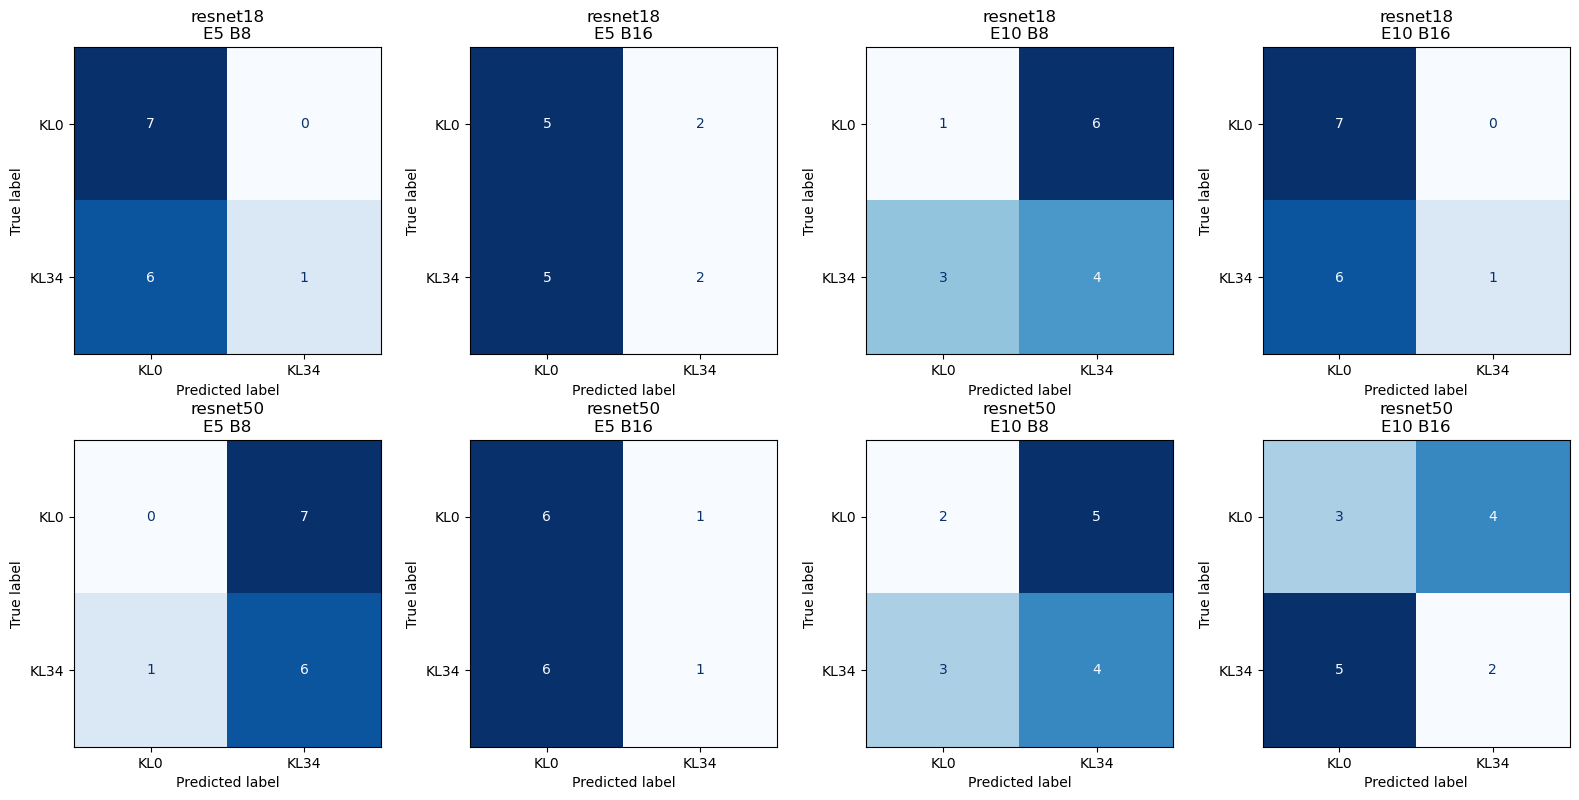

In [94]:
import os
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

wanted_files = [
    "resnet18_e5_b8.pth",
    "resnet18_e5_b16.pth",
    "resnet18_e10_b8.pth",
    "resnet18_e10_b16.pth",
    "resnet50_e5_b8.pth",
    "resnet50_e5_b16.pth",
    "resnet50_e10_b8.pth",
    "resnet50_e10_b16.pth",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, file in enumerate(wanted_files):
    path = os.path.join("saved_models", file)

    parts = file.replace(".pth", "").split("_")
    model_name = parts[0]
    epochs = int(parts[1][1:])
    batch_size = int(parts[2][1:])

    model = get_model(model_name)
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()

    _, _, test_loader = make_loaders(batch_size)

    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["KL0", "KL34"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{model_name}\nE{epochs} B{batch_size}")

plt.tight_layout()
plt.show()

In [95]:
def show_predictions(model, X_test, y_test, num_images=9, device="cpu"):
    model.eval()
    model.to(device)

    idxs = np.random.choice(len(X_test), size=min(num_images, len(X_test)), replace=False)

    plt.figure(figsize=(12, 10))

    for i, idx in enumerate(idxs):
        img = X_test[idx]                       # (128, 128)
        inp = np.expand_dims(img, axis=0)       # (1, 128, 128)
        inp = np.repeat(inp, 3, axis=0)         # (3, 128, 128)
        inp = np.expand_dims(inp, axis=0)       # (1, 3, 128, 128)
        inp = torch.tensor(inp, dtype=torch.float32).to(device)

        with torch.no_grad():
            output = model(inp)
            pred = torch.argmax(output, dim=1).item()

        true_label = "KL0" if y_test[idx] == 0 else "KL34"
        pred_label = "KL0" if pred == 0 else "KL34"
        color = "green" if pred == y_test[idx] else "red"

        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"T:{true_label} | P:{pred_label}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [85]:
import torch

def load_saved_model(model_name, model_path, device="cpu"):
    model = get_model(model_name)   # uses your existing function
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    return model

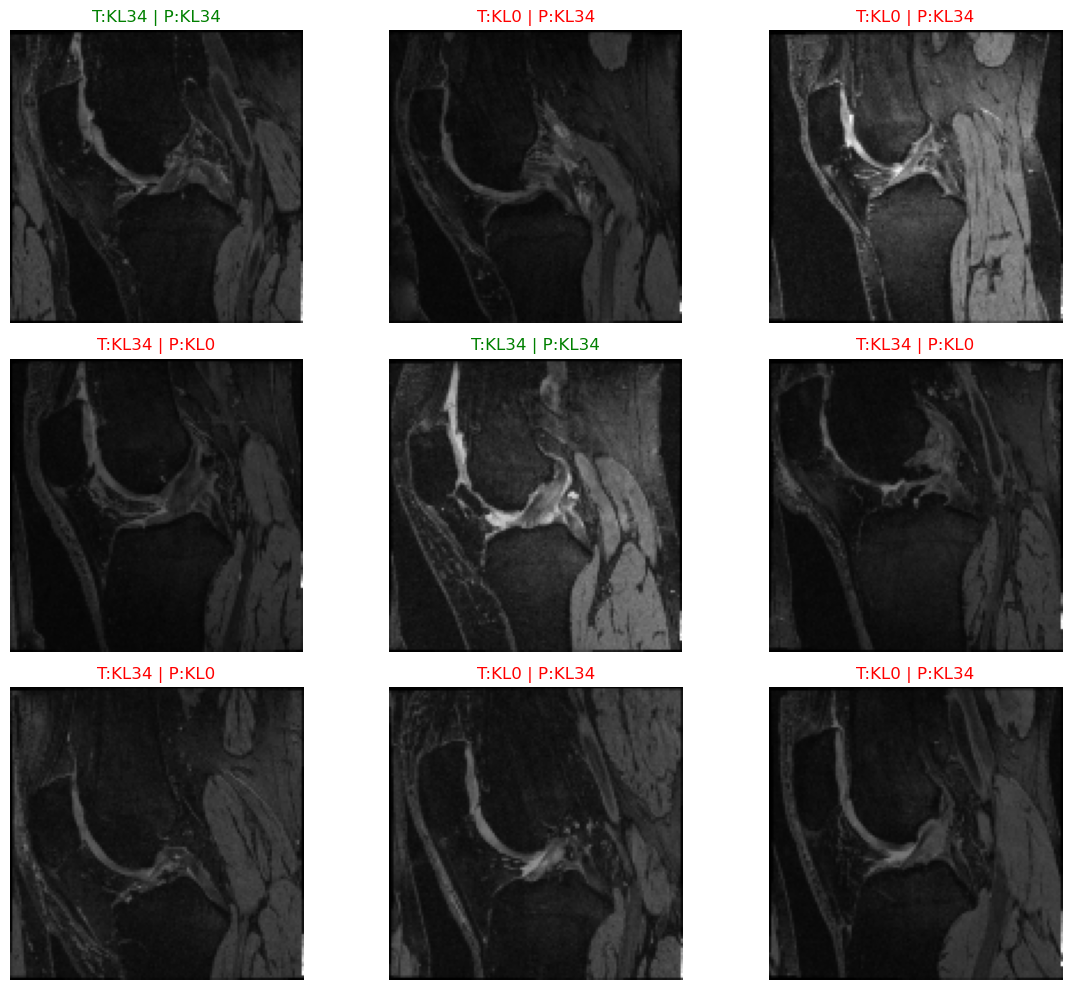

In [96]:
best_model = load_saved_model("resnet18", "saved_models/resnet18_e10_b8.pth", device=device)
show_predictions(best_model, X_test, y_test, num_images=9, device=device)